In [2]:
import pandas as pd
import numpy as np
import protfasta

# Compiling test sequences
Plan: 
- ARF
- Pdr1
- Sanborn nuclear proteins
- Hummel
- Erkine
- Drosophila
- Some GSL

# 1. ARF

In [130]:
arf_scores = pd.read_csv("../data/arf_scores_NIHMS2033317-supplement-Table_S3.csv")
arf_scores = arf_scores.rename(columns = {"Fragment Sequence" : "protein sequence", "ScaleScore" : "activity"})
arf_scores["id"] = "arf" + "_" + arf_scores["Model"] + "_" + arf_scores["Start Position"].astype(str)
arf_scores = arf_scores[["id", "protein sequence", "activity"]]
arf_scores

,id,protein sequence,activity
0,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN,0.132163
1,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,TAFSPAKKKLRLSPHLDFPIDSTFHPLSSNIDPTFASLSS,0.698559
2,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,RLSPHLDFPIDSTFHPLSSNIDPTFASLSSNLNPTPLTSS,1.002289
3,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,DSTFHPLSSNIDPTFASLSSNLNPTPLTSSMPRPTNPFQG,0.216912
4,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,IDPTFASLSSNLNPTPLTSSMPRPTNPFQGLPDYHVPAGI,-0.182901
...,...,...,...
9538,arf_ARF7_AD2_DEtoA_1,GANNRQQNFLAPTFGLAGASRNSLLGGANVANGFVPATLL,-0.119703
9539,arf_ARF19_AD1_minusswapplus_1,PPFFDPEYPDQPGMPRRKLRMKNAFEDAMPWMGKRFGMER,-0.348388
9540,arf_ARF19_AD2_minusswapplus_1,SQLQQQSMLPTGAEMTHQNINSMGNEGLSQMTSFAQKMQF,-0.758803
9541,arf_ARF7_AD1_minusswapplus_1,PPFFDPDFSGQPGMPRRKTRMKSALEDAMPWLRNSLKMER,-0.394609


# 2. Sanborn pdr1 and nuclear proteins

In [131]:
mutants = pd.read_csv("../data/53 aa mutants, see Fig 2,4,7-Table 1.csv")
short_mutants = pd.read_csv("../data/cAD muts and 9mers, see Fig 3,4-Table 1.csv")
nuclear = pd.read_csv("../data/Nuclear proteins, see Fig 7-Table 1.csv")
all_sanborn = pd.concat([mutants, short_mutants, nuclear])
all_sanborn["id"] = "sanborn" + "_" + all_sanborn["Unnamed: 0"]
all_sanborn = all_sanborn.rename(columns = {"Z score" : "activity"})
all_sanborn = all_sanborn[["id", "protein sequence", "activity"]]
all_sanborn

,id,protein sequence,activity
0,sanborn_D_ADbest-AA-muts_P07248_415_DE,SENQPEFVEFQELLENETLGNELLETTAVLKEFELLHEESVSATAT...,4.55
1,sanborn_D_ADbest-AA-muts_P07248_415_ED,SDNQPDFVDFQDLLDNDTLGNDLLDTTAVLKDFDLLHDDSVSATAT...,6.51
2,sanborn_D_ADbest-AA-muts_P07248_648_DE,LPHFPIIHPSLLELELESLQRYTNEEGYEEAENAQLFERLSQGTEK...,3.49
3,sanborn_D_ADbest-AA-muts_P07248_648_ED,LPHFPIIHPSLLDLDLDSLQRYTNDDGYDDADNAQLFDRLSQGTDK...,4.70
4,sanborn_D_ADbest-AA-muts_P07269_0_DE,MMEEFSYEHEFNTHFATELEYLQHEQQQQQQQQHEQQHNQQQQPQP...,3.55
...,...,...,...
2066,sanborn_D_nuc-nonhits_Q03656_575,LLGAPWGCGADIWSTACLIFELITGDFLFEPDEGHSYTKDDDHIAQ...,-0.20
2067,sanborn_D_nuc-nonhits_P17883_860,QVLRLFIWIESKVDTLPVESLVSIFENSQFSGSEEIDSVDNIKIDT...,-0.22
2068,sanborn_D_nuc-nonhits_P53036_375,QRDPVYLGHLLYELTMHMEDFYALLIKLENDDDDDHDTASKALPSV...,-0.22
2069,sanborn_D_nuc-nonhits_P22211_487,EYCIGTTLNHPNIIETIEIVYENDRILQVMEYCEYDLFAIVMSNKM...,-0.29


# 3. Hummel

In [133]:
hummel = pd.read_csv("../data/hummel_ratio_20230530 new analysis with better data.csv")
hummel["id"] = "hummel" + "_" + hummel["Locus"] + "_" + hummel["Position"].astype(str)
hummel = hummel.rename(columns= {"Predicted_activation" : "activity", "protein" : "protein sequence"})
hummel = hummel[["id", "protein sequence", "activity"]]
hummel

,id,protein sequence,activity
0,hummel_YJR074W_77,FEDGLATNESIIVDLLETVDKSDLKEAWQFHVEDLTELNGTTKWEA...,19.936405
1,hummel_YKR023W_32,VLSTSSDDPEQIASKFLEFLGHEDLSFEFVMKFNELLNQNDKKEEK...,34.496650
2,hummel_YHR158C_851,DKVNELEELVNSKFLDIENLNEVIQFQNEKIKSLELEPNYKEKLEE...,19.182789
3,hummel_AT2G40120.1_127,ETEDEDEFMSPAFRESDCFILPENAEDKFITDNQFENSLGVYDRSS...,22.673100
4,hummel_AT2G29920.1_98,SDLDLELLLLHQDHDLELLLTDSDFDLELLPLHQDHDLELLLPDSE...,28.213512
...,...,...,...
16247,hummel_AT3G54000.1_1,MEPPSSVVDDAEFWLPTEFLTDDDFLVEKENNSVGIDDSLFPYEPR...,42.758553
16248,hummel_AT1G50780.1_230,LVNEDAGFVDCLFETEEEKNRMIVPQETQTQPMFSEEDQSFWENLD...,69.020920
16249,hummel_AT1G50780.1_246,EEKNRMIVPQETQTQPMFSEEDQSFWENLDVDDVFGLFNDDTNLEV...,68.433680
16250,hummel_AT1G50780.1_252,IVPQETQTQPMFSEEDQSFWENLDVDDVFGLFNDDTNLEVPLQDHS...,72.636330


# 4. Erkine Ravarani

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,id,protein sequence,activity
0,ravarani_seq_1,NLGSTLSDLEYVCFGGYDYS,353.2529
1,ravarani_seq_2,TGWDGVGIGCLSAEPEWLKL,93.7170
2,ravarani_seq_3,DGGSSFLESRYENWCGNRWS,76.4687
3,ravarani_seq_4,PLSPPCCTSLLNENIEFWLL,48.2781
4,ravarani_seq_5,ISIEAGARDDCPLCEWAGTE,32.3524
...,...,...,...
27483,ravarani_seq_27484,TLFYLVHRADARTLLYSAAI,-0.2527
27484,ravarani_seq_27485,HSTNQSDDQEKIVPCSARDW,-0.2527
27485,ravarani_seq_27486,SGGSYSNGRGMGVSEEPNGP,-0.2528
27486,ravarani_seq_27487,GHRWILICDRYLLGWLASPS,-0.2528


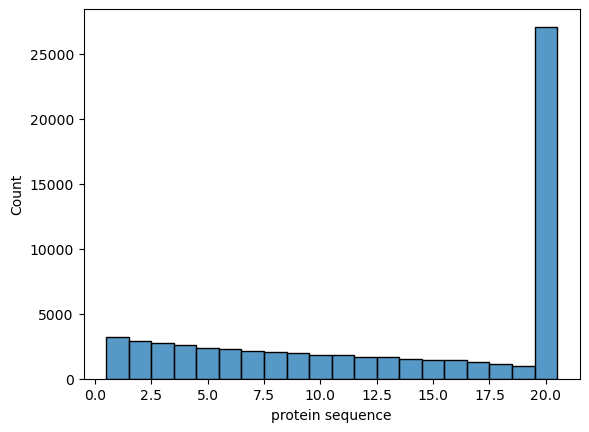

In [144]:
ravarani = pd.read_excel("../data/msb188190-sup-0002-tableev1.xlsx", sheet_name="Table EV1")
ravarani = ravarani.rename(columns = {"sequence" : "protein sequence", "growth_estimate" : "activity"})
ravarani["id"] = "ravarani_" + ravarani["id"]
ravarani = ravarani.drop(columns="class")
# Filter to 20 mers because there's a lot of short stuff
sns.histplot(ravarani["protein sequence"].str.len(), discrete=True)
ravarani = ravarani[ravarani["protein sequence"].str.len() == 20]
ravarani

# 5. Arnold
I used FC>=1.5, P<=1E-5 sequences. Seems like only positives are listed in their data, not negatives

In [129]:
# Read a specific sheet from the Excel file
ev2 = pd.read_excel("../data/embj201798896-sup-0004-table_ev2.xlsx", sheet_name="FC>=1.5, P<=1E-5")
ev2["id"] = "arnold_" + ev2["TF_name"] + "_" + ev2["start tAD [relative to TF CDS]"].astype(str) + "_" + ev2["end tAD [relative to TF CDS]"].astype(str)
ev2 = ev2[["id", "tAD sequence [aa]", "enrichment (log2)"]]
ev2 = ev2.rename(columns = {"tAD sequence [aa]": "protein sequence", "enrichment (log2)": "activity"})
ev2.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,id,protein sequence,activity
0,arnold_HLH3B_FBtr0070506_303_918,LNGNQADANRSLSSSPRSHSRNGLLTAPASSGSSVGGSGGGGGNGS...,7.01428
1,arnold_MTF-1_FBtr0113324_495_1032,YAAEEEIPSPWIDAGVLVSKPIIPMAPLTDACVALPTEMPSFVNLK...,3.86131
2,arnold_sage_FBtr0081982_174_402,CPAVSLNYTLTADGAGLLAYAPTHPHSYSPSVMGGYEKEAHNMGLL...,2.94724
3,arnold_CG14451_FBtr0078538_582_792,SDRLIFRKSSQETHGKSRYLQAEDWRFLFEMEQLVRGIDDGLVRDP...,3.57737
4,arnold_bin_FBtr0076900_1632_1884,YAPTASLVAAGYSYATSAGSLDNGLRSISLQQLPGLSSIQHAQAQA...,2.48625


In [135]:
# Read a specific sheet from the Excel file
ev4 = pd.read_excel("../data/embj201798896-sup-0006-table_ev4.xlsx", sheet_name="FC>=1.5, P<=1E-5")
ev4["id"] = "arnold_" + ev4["TF_name"] + "_" + ev4["start tAD [relative to TF CDS]"].astype(str) + "_" + ev4["end tAD [relative to TF CDS]"].astype(str)
ev4 = ev4[["id", "tAD sequence [aa]", "enrichment (log2)"]]
ev4 = ev4.rename(columns = {"tAD sequence [aa]": "protein sequence", "enrichment (log2)": "activity"})
ev4.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,id,protein sequence,activity
0,arnold_Oaz_FBtr0302926_3453_3681,AAGGPFQLRPNPTWTCLMRHLFYFNVLLFIWMILWFIFHSG,2.55841
1,arnold_rgr_FBtr0088692_948_1170,DTPQKVHPLKVPQTRLVLSTQGVHLFQLAAVSAPQLL,1.67517
2,arnold_CG5204_FBtr0080433_1292_1656,ARCSGCPKTAMRTLKNLLQWRQIFGFLWQNFCDLPIARSCFYAAIT...,1.53217
3,arnold_BEAF-32_FBtr0305588_345_630,LQVVLQLLGRAAAGGRGGHHSSLYARTNTDGPATSTGW,1.37531
4,arnold_fu2_FBtr0079674_432_735,LDVAKVAAVRCVGIVCSQLVLLTLGGQSEPKITVLTEERSFWPCLR...,1.47299


In [136]:
# Read a specific sheet from the Excel file
ev5 = pd.read_excel("../data/embj201798896-sup-0007-table_ev5.xlsx", sheet_name="FC>=1.5, P<=1E-5")
ev5["id"] = "arnold_" + ev5["TF_name"] + "_" + ev5["start tAD [relative to TF CDS]"].astype(str) + "_" + ev5["end tAD [relative to TF CDS]"].astype(str)
ev5 = ev5[["id", "tAD sequence [aa]", "enrichment (log2)"]]
ev5 = ev5.rename(columns = {"tAD sequence [aa]": "protein sequence", "enrichment (log2)": "activity"})
ev5.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,id,protein sequence,activity
0,arnold_MTF-1_FBtr0113324_0.0_1530.0,MRTHTQERPYKCPEDDCGKAFTASHHLKTHRRTHTGEKPYPCQEDS...,7.13179
1,arnold_Clk_FBtr0076785_1773.0_3069.0,AGNACQFPQPAYPLASPQLVAPTFLEPPQYLTAIPMQPVIAPFPVA...,6.30373
2,arnold_HLH3B_FBtr0070506_0.0_1086.0,MAWLPSSSNGADNADERSTASSGSSGHSQTNESPRSGHLNGNGSMR...,4.30270
3,arnold_tap_FBtr0075216_114.0_1140.0,QLSSRRRLDFGTPPTPAIPQPYSGGTWDAVPLSSPPAGFVGLLDTS...,3.09070
4,arnold_CG32105_FBtr0075953_381.0_1344.0,SNSNHNNNNNNNNGGSSSNNLHSACNTLTAAAVAAASAAAVAAPSP...,2.78646


In [137]:
# Read a specific sheet from the Excel file
ev6 = pd.read_excel("../data/embj201798896-sup-0008-table_ev6.xlsx", sheet_name="FC>=1.5, pv<=1E-5")
ev6["id"] = "arnold_" + ev6["TF_name"] + "_" + ev6["start tAD [relative to TF CDS]"].astype(str) + "_" + ev6["end tAD [relative to TF CDS]"].astype(str)
ev6 = ev6[["id", "tAD sequence [aa]", "enrichment (log2)"]]
ev6 = ev6.rename(columns = {"tAD sequence [aa]": "protein sequence", "enrichment (log2)": "activity"})
ev6.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,id,protein sequence,activity
0,arnold_ase_FBtr0070075_1098_1458,NGQIGACTIRFRCMCLPPVNGIDHALVRKAASGCIVGLILLQNIAE...,2.24070
1,arnold_Sox15_FBtr0087576_1441_2317,WIMVTPSRAHSIHQYPFRKMTIAPQCGTALVLCSSTVMWSQVHPQA...,2.67601
2,arnold_CG13287_FBtr0077027_457_1252,PVWSYPWWILQRHHQLLHHHRPCAALLPK,2.42047
3,arnold_CG7839_FBtr0076207_2620_3445,TRCSSSTSWSINVDRRKLWRRTKSKRRSRRTPQKREMMARLERNT,3.35425
4,arnold_chn_FBtr0087416_1498_1978,TARGLERTSGVSSGTSIRIQSPSFACSAITRRRVPSAWPPMC,1.56189


In [138]:
arnold = pd.concat([ev2, ev4, ev5, ev6])
arnold

,id,protein sequence,activity
0,arnold_HLH3B_FBtr0070506_303_918,LNGNQADANRSLSSSPRSHSRNGLLTAPASSGSSVGGSGGGGGNGS...,7.01428
1,arnold_MTF-1_FBtr0113324_495_1032,YAAEEEIPSPWIDAGVLVSKPIIPMAPLTDACVALPTEMPSFVNLK...,3.86131
2,arnold_sage_FBtr0081982_174_402,CPAVSLNYTLTADGAGLLAYAPTHPHSYSPSVMGGYEKEAHNMGLL...,2.94724
3,arnold_CG14451_FBtr0078538_582_792,SDRLIFRKSSQETHGKSRYLQAEDWRFLFEMEQLVRGIDDGLVRDP...,3.57737
4,arnold_bin_FBtr0076900_1632_1884,YAPTASLVAAGYSYATSAGSLDNGLRSISLQQLPGLSSIQHAQAQA...,2.48625
...,...,...,...
8,arnold_CG32767_FBtr0302119_1499_1961,GNGDCDHQLPVRRVCGEVRF,1.31087
9,arnold_CG7839_FBtr0076207_1178_1469,IKGSVPRVLEERYAGPADWTGTQ,1.28166
10,arnold_phol_FBtr0076475_149_1049,SSSPLTSPINALTTSSTSVTAEALNGSGRMTYSLPMPSLKTSWLIM...,4.20242
11,arnold_tup_FBtr0081112_977_1394,RTALHTVIALQVGDVGVGAVRMVVRGDPGVQTAASGLLVRLLVLMV...,3.03372


# 6. DelRosso Sample

In [172]:
all_delrosso = pd.read_excel("../data/41586_2023_5906_MOESM5_ESM.xlsx", sheet_name="CRTF Tiles", 
                         usecols=["HGNC Symbol", "Tile Start", "Tile End", "Avg_minCMV"])
all_delrosso = all_delrosso.dropna()
all_delrosso

,HGNC Symbol,Tile Start,Tile End,Avg_minCMV
0,A1CF,1,80,1.729123
1,A1CF,11,90,3.092911
2,A1CF,21,100,4.513614
4,A1CF,41,120,6.285598
7,A1CF,71,150,6.378722
...,...,...,...,...
113521,ZZZ3,771,850,3.554602
113523,ZZZ3,791,870,4.330218
113524,ZZZ3,801,880,5.507990
113526,ZZZ3,821,900,5.708663


In [162]:
import AD_predictor_tools

tiled_lambert_TFs = AD_predictor_tools.makeTilingDF("../data/lambert_TFs_10-21-24_with_DBD_coords.fasta", window_size=80, window_spacing=1)
tiled_lambert_TFs["StartPosition"] = tiled_lambert_TFs["StartPosition"] + 1
tiled_lambert_TFs["uniprotID"] = tiled_lambert_TFs["GeneName"].str.split("|").str[1]
tiled_lambert_TFs

Using existing Tiling DF at ../data/TilingDFs/lambert_TFs_10-21-24_with_DBD_coords_size_80_space_10_AAs_W,F,Y,M,L,Q.csv


,ProteinWindowSeq,GeneName,StartPosition,EndPosition,W,F,Y,M,L,Q,K,R,D,E,Charge,uniprotID
0,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,1,80,1,1,0,3,12,4,2,4,6,7,-7,A0A087WUV0
1,EDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEALTQWRQLNSP...,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,11,90,1,0,0,2,13,5,2,3,6,10,-11,A0A087WUV0
2,PKENDVTAVLLTPGSQELMIRDMAEALTQWRQLNSPQGDVPEKPRN...,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,21,100,1,0,0,2,11,6,4,4,4,10,-6,A0A087WUV0
3,LTPGSQELMIRDMAEALTQWRQLNSPQGDVPEKPRNLVLLGLPIST...,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,31,110,2,0,0,2,10,6,4,4,3,12,-7,A0A087WUV0
4,RDMAEALTQWRQLNSPQGDVPEKPRNLVLLGLPISTPDVISQLEHE...,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,41,120,2,0,0,1,9,5,5,4,4,14,-9,A0A087WUV0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84438,YKQYALYKKMTQAAILIQSKFRSYYEQKKFQQSRRAAVLIQKYYRS...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1561,1640,0,2,8,1,6,12,13,9,1,1,20,Q9Y6Y1
84439,TQAAILIQSKFRSYYEQKKFQQSRRAAVLIQKYYRSYKKCGKRRQA...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1571,1650,0,3,5,1,6,11,11,13,1,1,22,Q9Y6Y1
84440,FRSYYEQKKFQQSRRAAVLIQKYYRSYKKCGKRRQARRTAVIVQQK...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1581,1660,0,3,5,1,7,9,10,15,2,1,22,Q9Y6Y1
84441,QQSRRAAVLIQKYYRSYKKCGKRRQARRTAVIVQQKLRSSLLTKKQ...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1591,1670,0,1,4,1,7,8,10,16,2,2,22,Q9Y6Y1


In [165]:
HGNC_mapping = pd.read_csv("/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/data/lambert_tfs_gene_names.tsv", sep = "\t")
HGNC_mapping = HGNC_mapping.rename(columns = {"From":"uniprotID", "Gene Names (primary)": "HGNC Symbol"})
HGNC_mapping = HGNC_mapping[["uniprotID", "HGNC Symbol"]]
tiled_lambert_TFs = pd.merge(tiled_lambert_TFs, HGNC_mapping)
tiled_lambert_TFs


,ProteinWindowSeq,GeneName,StartPosition,EndPosition,W,F,Y,M,L,Q,K,R,D,E,Charge,uniprotID,HGNC Symbol
0,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,1,80,1,2,0,3,7,3,8,3,2,9,0,A0AVK6,E2F8
1,EPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPTKPKEGSQGEP...,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,11,90,1,2,0,2,8,3,7,5,3,6,3,A0AVK6,E2F8
2,PLKESTTANIVLAEIQPDFGPLTTPTKPKEGSQGEPWTPTANLKML...,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,21,100,1,2,0,1,7,3,6,4,4,7,-1,A0AVK6,E2F8
3,VLAEIQPDFGPLTTPTKPKEGSQGEPWTPTANLKMLISAVSPEIRN...,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,31,110,1,3,0,1,7,4,6,4,5,8,-3,A0AVK6,E2F8
4,PLTTPTKPKEGSQGEPWTPTANLKMLISAVSPEIRNRDQKRGLFDN...,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,41,120,1,2,0,1,8,3,8,5,4,8,1,A0AVK6,E2F8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83454,YKQYALYKKMTQAAILIQSKFRSYYEQKKFQQSRRAAVLIQKYYRS...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1561,1640,0,2,8,1,6,12,13,9,1,1,20,Q9Y6Y1,CAMTA1
83455,TQAAILIQSKFRSYYEQKKFQQSRRAAVLIQKYYRSYKKCGKRRQA...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1571,1650,0,3,5,1,6,11,11,13,1,1,22,Q9Y6Y1,CAMTA1
83456,FRSYYEQKKFQQSRRAAVLIQKYYRSYKKCGKRRQARRTAVIVQQK...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1581,1660,0,3,5,1,7,9,10,15,2,1,22,Q9Y6Y1,CAMTA1
83457,QQSRRAAVLIQKYYRSYKKCGKRRQARRTAVIVQQKLRSSLLTKKQ...,sp|Q9Y6Y1|CMTA1_HUMAN Calmodulin-binding trans...,1591,1670,0,1,4,1,7,8,10,16,2,2,22,Q9Y6Y1,CAMTA1


In [195]:
merged_data = pd.merge(all_delrosso, tiled_lambert_TFs[["HGNC Symbol", "ProteinWindowSeq"]], how="left").dropna()
merged_data

,HGNC Symbol,Tile Start,Tile End,Avg_minCMV,ProteinWindowSeq
327,ADNP,11,90,3.764766,MFQLPVNNLGSLRKARKTVKKILSDIGLEYCKEHIEDFKQFEPNDF...
328,ADNP,11,90,3.764766,SLRKARKTVKKILSDIGLEYCKEHIEDFKQFEPNDFYLKNTTWEDV...
329,ADNP,11,90,3.764766,KILSDIGLEYCKEHIEDFKQFEPNDFYLKNTTWEDVGLWDPSLTKN...
330,ADNP,11,90,3.764766,CKEHIEDFKQFEPNDFYLKNTTWEDVGLWDPSLTKNQDYRTKPFCC...
331,ADNP,11,90,3.764766,FEPNDFYLKNTTWEDVGLWDPSLTKNQDYRTKPFCCSACPFSSKFF...
...,...,...,...,...,...
4145309,ZXDC,778,857,-2.370535,QSTQRKIKEGKMSPPHFHASQNSWLCGSLVVPSGGRPGPAPAAGVQ...
4145310,ZXDC,778,857,-2.370535,KMSPPHFHASQNSWLCGSLVVPSGGRPGPAPAAGVQCGAQGVQVQL...
4145311,ZXDC,778,857,-2.370535,QNSWLCGSLVVPSGGRPGPAPAAGVQCGAQGVQVQLVQDDPSGEGV...
4145312,ZXDC,778,857,-2.370535,VPSGGRPGPAPAAGVQCGAQGVQVQLVQDDPSGEGVLPSARGPATF...


In [196]:
# Randomly select 100 TFs to use to test
len(merged_data["HGNC Symbol"].unique())

1241

In [197]:
import numpy as np

# Randomly sample 25 unique "HGNC Symbol" values
np.random.seed(42)  # Set random seed for reproducibility
sampled_symbols = np.random.choice(merged_data["HGNC Symbol"].unique(), size=25, replace=False)
sampled_symbols

array(['THAP12', 'CEBPG', 'FOXJ2', 'HOXA2', 'NR3C2', 'NR2C1', 'PKNOX2',
       'THRA', 'ZBTB20', 'MAFG', 'MBD6', 'ELF3', 'TEAD1', 'ZSCAN23',
       'ZNF121', 'SOX1', 'ZNF532', 'CREB3', 'ZNF683', 'ZNF80', 'NFE2L3',
       'NFATC2', 'L3MBTL3', 'ATOH8', 'NR2F1'], dtype=object)

In [198]:
merged_data_sampled = merged_data[merged_data["HGNC Symbol"].isin(sampled_symbols)]
merged_data_sampled

,HGNC Symbol,Tile Start,Tile End,Avg_minCMV,ProteinWindowSeq
227902,ATOH8,1,80,-3.438750,MKHIPVLEDGPWKTVCVKELNGLKKLKRKGKEPARRANGYKTFRLD...
227903,ATOH8,1,80,-3.438750,PWKTVCVKELNGLKKLKRKGKEPARRANGYKTFRLDLEAPEPRAVA...
227904,ATOH8,1,80,-3.438750,NGLKKLKRKGKEPARRANGYKTFRLDLEAPEPRAVATNGLRDRTHR...
227905,ATOH8,1,80,-3.438750,KEPARRANGYKTFRLDLEAPEPRAVATNGLRDRTHRLQPVPVPVPV...
227906,ATOH8,1,80,-3.438750,KTFRLDLEAPEPRAVATNGLRDRTHRLQPVPVPVPVPVPVAPAVPP...
...,...,...,...,...,...
4115588,ZSCAN23,291,370,4.291155,HTGEKPYECDECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQ...
4115589,ZSCAN23,291,370,4.291155,ECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRI...
4115590,ZSCAN23,291,370,4.291155,GLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCN...
4115591,ZSCAN23,291,370,4.291155,GEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCNQCNKSFSRRS...


In [199]:
merged_data_sampled["id"] = "delrosso" + "_" + merged_data_sampled["HGNC Symbol"] + "_" + merged_data_sampled["Tile Start"].astype(str) + "_" + merged_data_sampled["Tile End"].astype(str)
merged_data_sampled = merged_data_sampled.rename(columns = {"Avg_minCMV" : "activity",
                                            "ProteinWindowSeq" : "protein sequence"})
merged_data_sampled = merged_data_sampled[["id", "protein sequence", "activity"]]
delrosso = merged_data_sampled
delrosso

,id,protein sequence,activity
227902,delrosso_ATOH8_1_80,MKHIPVLEDGPWKTVCVKELNGLKKLKRKGKEPARRANGYKTFRLD...,-3.438750
227903,delrosso_ATOH8_1_80,PWKTVCVKELNGLKKLKRKGKEPARRANGYKTFRLDLEAPEPRAVA...,-3.438750
227904,delrosso_ATOH8_1_80,NGLKKLKRKGKEPARRANGYKTFRLDLEAPEPRAVATNGLRDRTHR...,-3.438750
227905,delrosso_ATOH8_1_80,KEPARRANGYKTFRLDLEAPEPRAVATNGLRDRTHRLQPVPVPVPV...,-3.438750
227906,delrosso_ATOH8_1_80,KTFRLDLEAPEPRAVATNGLRDRTHRLQPVPVPVPVPVPVAPAVPP...,-3.438750
...,...,...,...
4115588,delrosso_ZSCAN23_291_370,HTGEKPYECDECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQ...,4.291155
4115589,delrosso_ZSCAN23_291_370,ECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRI...,4.291155
4115590,delrosso_ZSCAN23_291_370,GLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCN...,4.291155
4115591,delrosso_ZSCAN23_291_370,GEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCNQCNKSFSRRS...,4.291155


# Saving test and train

In [215]:
test_seqs = pd.concat([arf_scores, all_sanborn, hummel, ravarani, arnold, delrosso]).dropna()
test_seqs = test_seqs.drop_duplicates()
test_seqs["group"] = "test"
test_seqs

,id,protein sequence,activity,group
0,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN,0.132163,test
1,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,TAFSPAKKKLRLSPHLDFPIDSTFHPLSSNIDPTFASLSS,0.698559,test
2,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,RLSPHLDFPIDSTFHPLSSNIDPTFASLSSNLNPTPLTSS,1.002289,test
3,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,DSTFHPLSSNIDPTFASLSSNLNPTPLTSSMPRPTNPFQG,0.216912,test
4,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,IDPTFASLSSNLNPTPLTSSMPRPTNPFQGLPDYHVPAGI,-0.182901,test
...,...,...,...,...
4115588,delrosso_ZSCAN23_291_370,HTGEKPYECDECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQ...,4.291155,test
4115589,delrosso_ZSCAN23_291_370,ECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRI...,4.291155,test
4115590,delrosso_ZSCAN23_291_370,GLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCN...,4.291155,test
4115591,delrosso_ZSCAN23_291_370,GEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCNQCNKSFSRRS...,4.291155,test


In [216]:
# Clustered by mmseqs >70% seq ident
# Disorder threshold
# Length threshold 
train_seqs = protfasta.read_fasta("../data/CL_SK_plant_seqs_disord_thresh.fasta")
train_seqs = pd.DataFrame({"id" : train_seqs.keys(), "protein sequence" : train_seqs.values()}).drop_duplicates()
train_seqs

,id,protein sequence
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
497978,Zpz_sc00227.1.g00450.1.am.mk Zoysia pacifica|b...,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...
497979,Zpz_sc01778.1.g00020.1.am.mk Zoysia pacifica|M...,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...
497980,Zpz_sc01095.1.g00030.1.sm.mk Zoysia pacifica|H...,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...
497981,Zpz_sc05215.1.g00010.1.am.mk Zoysia pacifica|b...,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...


In [217]:
cl_seqs = protfasta.read_fasta("../output/cl_seqs.fasta", invalid_sequence_action='remove')
cl_seqs_df = pd.DataFrame({"id": cl_seqs.keys(), "seq": cl_seqs.values()})
sk_seqs = protfasta.read_fasta("../output/interpro_uniprot_evid_1_2.fasta", invalid_sequence_action='ignore')
sk_seqs_df = pd.DataFrame({"id": sk_seqs.keys(), "seq": sk_seqs.values()})
sk_seqs_df["id"] = sk_seqs_df["id"].str.split("|").str[1]
plant_seqs = protfasta.read_fasta("../data/PlantTFDB-all_TF_pep.fas", invalid_sequence_action='ignore')
plant_seqs_df = pd.DataFrame({"id": plant_seqs.keys(), "seq": plant_seqs.values()})
plant_seqs_df["id"] = plant_seqs_df["id"].str.split(" ").str[0]
all_seqs = pd.concat([plant_seqs_df, cl_seqs_df,sk_seqs_df])
all_seqs

,id,seq
0,KFK36254.1,MYSAIRSLPVDGSMGEYSDGTNLPIEACLVLTTDPKPRLRWTTELH...
1,KFK25038.1,MAPKHTDTIQNPPMPSSSSEEESASSGEDSDSSKKHNSASDSDPIK...
2,KFK35037.1,MTTTTTPHWPDFSSQKLPSIAATAAATAATAGQNQQNQNPSWMDEF...
3,KFK44643.1,MEGERHDSTTSSSRKRSHEPAEERPASHVATMAFKEKPYRGIRMRK...
4,KFK32619.1,MAKPPQFFHTLVNTHLVIPKDFFSKYIQGKSVDDTVELKSDSTDIN...
...,...,...
137431,W8C846,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...
137432,W8CA25,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...
137433,W8QUS6,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...
137434,X5CQH7,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...


In [218]:
final_clusters = pd.read_csv("../output/mmseqs/CL_SK_plant_seqs_disord_thresh_DB_clu_id75.tsv", sep = "\t", header = None)[[0]].drop_duplicates()
final_clusters = final_clusters.rename(columns = {0 : "id"})
final_clusters = pd.merge(final_clusters, all_seqs).drop_duplicates(subset = "id")
final_clusters

,id,seq
0,Q8GGH0,MESFLLSKVSFVIKKIRLEKGMTQEDLAYKSNLDRTYISGIERNSR...
1,F1R2J1,MHEETSNSTLQGKTSFSIADILDPAKFNGTRETREISNNRESPKTT...
2,O75364,MEFGLLSEAEARSPALSLSDAGTPHPQLPEHGCKGQEHSDSEKASA...
3,P09087,MQQHHLQQQQQQQQQQEQQHLQEQQQHLQQLHHHAHHHLPQPLHTT...
4,P43609,MSDTEKDKDVPMVDSHEATEEPPTTSTNTPSFPHLAQEQAKEESAT...
...,...,...
243147,g004716.m1_yHMPu5000040912_saturnispora_halmia...,MQQKRAFPSNEGPNGDVNENQHGETIIANQETDRRGGMERDSEEAL...
243148,g002397.m1_yHMPu5000041691_saccharomycopsis_cr...,MSKRPGEETEEDTIKKLKIESQQPKDDNNVIDSELLTHQTNYQDDG...
243149,g002544.m1_yHDO593_barnettozyma_sp_180604.final,MDNISTPNQMEEQYTYLEEPAIIIDQNGGESQGLLTEQQQQQQQQL...
243150,g003106.m1_yHMPu5000034601_starmera_dryadoides...,QQQQQQQQQQQQQQQQQQPPPPPPPQQQVSESPNDPQPVQEVAVVE...


In [219]:
train_seqs = final_clusters.rename(columns = {"seq" : "protein sequence"})
train_seqs["group"] = "test"
train_seqs

,id,protein sequence,group
0,Q8GGH0,MESFLLSKVSFVIKKIRLEKGMTQEDLAYKSNLDRTYISGIERNSR...,test
1,F1R2J1,MHEETSNSTLQGKTSFSIADILDPAKFNGTRETREISNNRESPKTT...,test
2,O75364,MEFGLLSEAEARSPALSLSDAGTPHPQLPEHGCKGQEHSDSEKASA...,test
3,P09087,MQQHHLQQQQQQQQQQEQQHLQEQQQHLQQLHHHAHHHLPQPLHTT...,test
4,P43609,MSDTEKDKDVPMVDSHEATEEPPTTSTNTPSFPHLAQEQAKEESAT...,test
...,...,...,...
243147,g004716.m1_yHMPu5000040912_saturnispora_halmia...,MQQKRAFPSNEGPNGDVNENQHGETIIANQETDRRGGMERDSEEAL...,test
243148,g002397.m1_yHMPu5000041691_saccharomycopsis_cr...,MSKRPGEETEEDTIKKLKIESQQPKDDNNVIDSELLTHQTNYQDDG...,test
243149,g002544.m1_yHDO593_barnettozyma_sp_180604.final,MDNISTPNQMEEQYTYLEEPAIIIDQNGGESQGLLTEQQQQQQQQL...,test
243150,g003106.m1_yHMPu5000034601_starmera_dryadoides...,QQQQQQQQQQQQQQQQQQPPPPPPPQQQVSESPNDPQPVQEVAVVE...,test


In [220]:
train_seqs["group"] = "train"
train_seqs

,id,protein sequence,group
0,Q8GGH0,MESFLLSKVSFVIKKIRLEKGMTQEDLAYKSNLDRTYISGIERNSR...,train
1,F1R2J1,MHEETSNSTLQGKTSFSIADILDPAKFNGTRETREISNNRESPKTT...,train
2,O75364,MEFGLLSEAEARSPALSLSDAGTPHPQLPEHGCKGQEHSDSEKASA...,train
3,P09087,MQQHHLQQQQQQQQQQEQQHLQEQQQHLQQLHHHAHHHLPQPLHTT...,train
4,P43609,MSDTEKDKDVPMVDSHEATEEPPTTSTNTPSFPHLAQEQAKEESAT...,train
...,...,...,...
243147,g004716.m1_yHMPu5000040912_saturnispora_halmia...,MQQKRAFPSNEGPNGDVNENQHGETIIANQETDRRGGMERDSEEAL...,train
243148,g002397.m1_yHMPu5000041691_saccharomycopsis_cr...,MSKRPGEETEEDTIKKLKIESQQPKDDNNVIDSELLTHQTNYQDDG...,train
243149,g002544.m1_yHDO593_barnettozyma_sp_180604.final,MDNISTPNQMEEQYTYLEEPAIIIDQNGGESQGLLTEQQQQQQQQL...,train
243150,g003106.m1_yHMPu5000034601_starmera_dryadoides...,QQQQQQQQQQQQQQQQQQPPPPPPPQQQVSESPNDPQPVQEVAVVE...,train


In [221]:
train_test_legend = pd.concat([test_seqs, train_seqs[["id", "protein sequence", "group"]]])
train_test_legend

,id,protein sequence,activity,group
0,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN,0.132163,test
1,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,TAFSPAKKKLRLSPHLDFPIDSTFHPLSSNIDPTFASLSS,0.698559,test
2,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,RLSPHLDFPIDSTFHPLSSNIDPTFASLSSNLNPTPLTSS,1.002289,test
3,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,DSTFHPLSSNIDPTFASLSSNLNPTPLTSSMPRPTNPFQG,0.216912,test
4,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,IDPTFASLSSNLNPTPLTSSMPRPTNPFQGLPDYHVPAGI,-0.182901,test
...,...,...,...,...
243147,g004716.m1_yHMPu5000040912_saturnispora_halmia...,MQQKRAFPSNEGPNGDVNENQHGETIIANQETDRRGGMERDSEEAL...,NaN,train
243148,g002397.m1_yHMPu5000041691_saccharomycopsis_cr...,MSKRPGEETEEDTIKKLKIESQQPKDDNNVIDSELLTHQTNYQDDG...,NaN,train
243149,g002544.m1_yHDO593_barnettozyma_sp_180604.final,MDNISTPNQMEEQYTYLEEPAIIIDQNGGESQGLLTEQQQQQQQQL...,NaN,train
243150,g003106.m1_yHMPu5000034601_starmera_dryadoides...,QQQQQQQQQQQQQQQQQQPPPPPPPQQQVSESPNDPQPVQEVAVVE...,NaN,train


In [222]:
# Give each a a numerical key for easier mapping back
train_test_legend["num_key"] = np.arange(len(train_test_legend))
train_test_legend

,id,protein sequence,activity,group,num_key
0,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN,0.132163,test,0
1,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,TAFSPAKKKLRLSPHLDFPIDSTFHPLSSNIDPTFASLSS,0.698559,test,1
2,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,RLSPHLDFPIDSTFHPLSSNIDPTFASLSSNLNPTPLTSS,1.002289,test,2
3,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,DSTFHPLSSNIDPTFASLSSNLNPTPLTSSMPRPTNPFQG,0.216912,test,3
4,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,IDPTFASLSSNLNPTPLTSSMPRPTNPFQGLPDYHVPAGI,-0.182901,test,4
...,...,...,...,...,...
243147,g004716.m1_yHMPu5000040912_saturnispora_halmia...,MQQKRAFPSNEGPNGDVNENQHGETIIANQETDRRGGMERDSEEAL...,NaN,train,357656
243148,g002397.m1_yHMPu5000041691_saccharomycopsis_cr...,MSKRPGEETEEDTIKKLKIESQQPKDDNNVIDSELLTHQTNYQDDG...,NaN,train,357657
243149,g002544.m1_yHDO593_barnettozyma_sp_180604.final,MDNISTPNQMEEQYTYLEEPAIIIDQNGGESQGLLTEQQQQQQQQL...,NaN,train,357658
243150,g003106.m1_yHMPu5000034601_starmera_dryadoides...,QQQQQQQQQQQQQQQQQQPPPPPPPQQQVSESPNDPQPVQEVAVVE...,NaN,train,357659


In [ ]:
# 0 - 114509 = test
# 114509 + = train
train_test_legend[train_test_legend["group"] == "test"]

,id,protein sequence,activity,group,num_key
0,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN,0.132163,test,0
1,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,TAFSPAKKKLRLSPHLDFPIDSTFHPLSSNIDPTFASLSS,0.698559,test,1
2,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,RLSPHLDFPIDSTFHPLSSNIDPTFASLSSNLNPTPLTSS,1.002289,test,2
3,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,DSTFHPLSSNIDPTFASLSSNLNPTPLTSSMPRPTNPFQG,0.216912,test,3
4,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,IDPTFASLSSNLNPTPLTSSMPRPTNPFQGLPDYHVPAGI,-0.182901,test,4
...,...,...,...,...,...
4115588,delrosso_ZSCAN23_291_370,HTGEKPYECDECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQ...,4.291155,test,114505
4115589,delrosso_ZSCAN23_291_370,ECGRAFSQRSGLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRI...,4.291155,test,114506
4115590,delrosso_ZSCAN23_291_370,GLFQHQRLHTGEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCN...,4.291155,test,114507
4115591,delrosso_ZSCAN23_291_370,GEKRYQCSVCGKAFSQNAGLFHHLRIHTGEKPYQCNQCNKSFSRRS...,4.291155,test,114508


In [224]:
train_test_legend["group"].value_counts()

group
train    243151
test     114510
Name: count, dtype: int64

In [ ]:
#protfasta.write_fasta(dict(zip(train_test_legend["num_key"], train_test_legend["protein sequence"])), "../output/train_test_to_cluster.fasta")

In [212]:
train_subset = train_test_legend[train_test_legend["group"] == "train"]
protfasta.write_fasta(dict(zip(train_subset["num_key"], train_subset["protein sequence"])), "../data/train_seqs_for_mmseqs_search.fasta")

In [225]:
test_subset = train_test_legend[train_test_legend["group"] == "test"]
protfasta.write_fasta(dict(zip(test_subset["num_key"], test_subset["protein sequence"])), "../data/test_seqs_for_mmseqs_search.fasta")

# Clustering initial approach
This was previously done with just ARF and saborn sequences, but did not work because could not handle shorter subsequences

In [91]:
# From input data clusters with min identity .ipynb

def db_name(prefix, min_seq_id=0.5, fasta_path=False):
    if fasta_path:
        print(f"mmseqs createdb {fasta_path} {prefix}_DB") # - this alr exists
    id_thresh = int(min_seq_id * 100)
    print(f"mmseqs cluster {prefix}_DB {prefix}_DB_clu_id{id_thresh} {prefix}tmp_id{id_thresh} --min-seq-id {min_seq_id}")                      
    print(f"mmseqs createtsv {prefix}_DB {prefix}_DB {prefix}_DB_clu_id{id_thresh} {prefix}_DB_clu_id{id_thresh}.tsv")


In [99]:
db_name("test_train", 0.75, "../../output/train_test_to_cluster.fasta")

mmseqs createdb ../../output/train_test_to_cluster.fasta test_train_DB
mmseqs cluster test_train_DB test_train_DB_clu_id75 test_traintmp_id75 --min-seq-id 0.75
mmseqs createtsv test_train_DB test_train_DB test_train_DB_clu_id75 test_train_DB_clu_id75.tsv


In [100]:
test_train_clusters = pd.read_csv("../data/mmseqs/test_train_DB_clu_id75.tsv", sep = "\t", header = None)
test_train_clusters

,0,1
0,143781,143781
1,143813,143813
2,143845,143845
3,143877,143877
4,143909,143909
...,...,...
261300,228395,228395
261301,228427,228427
261302,228459,228459
261303,228491,228491


In [101]:
# 10,000 seqs removed
test_train_clusters[0].value_counts()

0
14086    447
15928    198
13175    178
13537    162
13702    137
        ... 
48286      1
48318      1
48350      1
48382      1
47902      1
Name: count, Length: 253032, dtype: int64

In [105]:
# 0 - 18153 = test
# 18154 + = train

test_train_clusters["cluster_leader_group"] = np.where(test_train_clusters[0] <= 18153, 'test', 'train')
test_train_clusters["cluster_member_group"] = np.where(test_train_clusters[1] <= 18153, 'test', 'train')
test_train_clusters

,0,1,cluster_leader_group,cluster_member_group
0,143781,143781,train,train
1,143813,143813,train,train
2,143845,143845,train,train
3,143877,143877,train,train
4,143909,143909,train,train
...,...,...,...,...
261300,228395,228395,train,train
261301,228427,228427,train,train
261302,228459,228459,train,train
261303,228491,228491,train,train


In [108]:
temp = test_train_clusters[test_train_clusters["cluster_leader_group"] == "test"]
temp[0].value_counts()

0
14086    447
15928    198
13175    178
13537    162
13702    137
        ... 
12179      1
12211      1
12243      1
12275      1
11987      1
Name: count, Length: 10513, dtype: int64

In [106]:
test_train_clusters[test_train_clusters["cluster_leader_group"] != test_train_clusters["cluster_member_group"]]

,0,1,cluster_leader_group,cluster_member_group


In [ ]:
# There are no clusters where train member is clustered with a test sequence...
# But this is wrong because the cluster sequences were of different length

# Clustering redone diy attempt
This was previously done with just ARF and saborn sequences, but did not work because run time too long

In [111]:
train_seqs

,id,protein sequence,group
0,Q8GGH0,MESFLLSKVSFVIKKIRLEKGMTQEDLAYKSNLDRTYISGIERNSR...,train
1,F1R2J1,MHEETSNSTLQGKTSFSIADILDPAKFNGTRETREISNNRESPKTT...,train
2,O75364,MEFGLLSEAEARSPALSLSDAGTPHPQLPEHGCKGQEHSDSEKASA...,train
3,P09087,MQQHHLQQQQQQQQQQEQQHLQEQQQHLQQLHHHAHHHLPQPLHTT...,train
4,P43609,MSDTEKDKDVPMVDSHEATEEPPTTSTNTPSFPHLAQEQAKEESAT...,train
...,...,...,...
243147,g004716.m1_yHMPu5000040912_saturnispora_halmia...,MQQKRAFPSNEGPNGDVNENQHGETIIANQETDRRGGMERDSEEAL...,train
243148,g002397.m1_yHMPu5000041691_saccharomycopsis_cr...,MSKRPGEETEEDTIKKLKIESQQPKDDNNVIDSELLTHQTNYQDDG...,train
243149,g002544.m1_yHDO593_barnettozyma_sp_180604.final,MDNISTPNQMEEQYTYLEEPAIIIDQNGGESQGLLTEQQQQQQQQL...,train
243150,g003106.m1_yHMPu5000034601_starmera_dryadoides...,QQQQQQQQQQQQQQQQQQPPPPPPPQQQVSESPNDPQPVQEVAVVE...,train


In [13]:
test_seqs

,protein sequence,id,group
0,VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
1,TAFSPAKKKLRLSPHLDFPIDSTFHPLSSNIDPTFASLSS,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
2,RLSPHLDFPIDSTFHPLSSNIDPTFASLSSNLNPTPLTSS,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
3,DSTFHPLSSNIDPTFASLSSNLNPTPLTSSMPRPTNPFQG,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
4,IDPTFASLSSNLNPTPLTSSMPRPTNPFQGLPDYHVPAGI,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
...,...,...,...
2066,LLGAPWGCGADIWSTACLIFELITGDFLFEPDEGHSYTKDDDHIAQ...,sanborn_D_nuc-nonhits_Q03656_575,test
2067,QVLRLFIWIESKVDTLPVESLVSIFENSQFSGSEEIDSVDNIKIDT...,sanborn_D_nuc-nonhits_P17883_860,test
2068,QRDPVYLGHLLYELTMHMEDFYALLIKLENDDDDDHDTASKALPSV...,sanborn_D_nuc-nonhits_P53036_375,test
2069,EYCIGTTLNHPNIIETIEIVYENDRILQVMEYCEYDLFAIVMSNKM...,sanborn_D_nuc-nonhits_P22211_487,test


In [ ]:
# look through all protein sequences in test_seqs
# For each, loop through all protein sequences in test_seqs
# If it matches train_seqs

In [14]:
import regex as re

In [44]:
# fuzzy match format
print(re.search(r'(ELL){e<=3}O', "HALLO"))
print(re.search(r'(ELL){e<=3}O', "HEEEO"))
print(re.search(r'(ELL){e<=3}O', "HELLO"))

<regex.Match object; span=(0, 5), match='HALLO', fuzzy_counts=(2, 1, 0)>
<regex.Match object; span=(1, 5), match='EEEO', fuzzy_counts=(2, 0, 0)>
<regex.Match object; span=(0, 5), match='HELLO', fuzzy_counts=(2, 1, 0)>


In [64]:
regex_test = re.search(r'(ELL){e<=3}O', "asdf;laksdfj")
str(regex_test.string)

AttributeError: 'NoneType' object has no attribute 'string'

In [ ]:
# Checking for fuzzy matches
train_seqs = train_seqs.drop_duplicates(subset="protein sequence").sort_values(by = 'protein sequence')
test_seqs_unique = test_seqs.drop_duplicates(subset="protein sequence")
display(train_seqs)
display(test_seqs_unique)

,id,protein sequence
53636,tr|A0A6A7FM55|A0A6A7FM55_9CRUS Homeobox protei...,AAAAAAAAAAAAAAARLCAGPGQQAMASYGQSLGYQQAAAQYNGPG...
52771,tr|A0A2P2I281|A0A2P2I281_9CRUS Homeobox protei...,AAAAAAAAAAAAAARLCAGPGQQAMASYGQSLGYQQAAAQYNGPGY...
204571,g004140.m1_yHMPu5000034864_zygosaccharomyces_l...,AAAAAAAAAAAGAGAGAAPVGGFIDPNLLNNSLFMDTFGLSPPSND...
93037,tr|Q69YM3|Q69YM3_HUMAN Uncharacterized protein...,AAAAAAAAAAEAGLHVSALGPHPPAAHLRSLKSLEPEDEVEDDPKV...
73597,tr|V9LK08|V9LK08_CALMI Histone H1x-like protei...,AAAAAAAAASASAAAASGVGGAKKKKKSGKKNQGKYSILLYDLVKQ...
...,...,...
120550,g008801.m1_yHMPu5000041701_Candida_jeffriesii_...,YYVSPPGYIPQSLLPPHVAAQYEENNALMNKRRIIKRRTRTGCLTC...
72416,tr|A6MZC6|A6MZC6_ORYSI 40S ribosomal protein S...,YYWYLTNDGIEHLRNYLNLPSEIVPATLKKSARPPGRPFGSGPPGD...
72073,tr|A0A2L0A422|A0A2L0A422_9TELE ETS domain-cont...,YYYDKNIIKKVIGQKFVYKFVSFPDILKMDPQAVELGRDGGHVAGG...
179761,g004501.m1_yHMPu5000034955_hanseniaspora_valby...,YYYQNQQDQQPQQAQQQQPQQQQQQQYAQYYHQTLPQGYYYAQGPD...


,protein sequence,id,group
0,VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
1,TAFSPAKKKLRLSPHLDFPIDSTFHPLSSNIDPTFASLSS,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
2,RLSPHLDFPIDSTFHPLSSNIDPTFASLSSNLNPTPLTSS,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
3,DSTFHPLSSNIDPTFASLSSNLNPTPLTSSMPRPTNPFQG,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
4,IDPTFASLSSNLNPTPLTSSMPRPTNPFQGLPDYHVPAGI,arf_evm_27.TU.AmTr_v1.0_scaffold00148.24|evm_2...,test
...,...,...,...
2066,LLGAPWGCGADIWSTACLIFELITGDFLFEPDEGHSYTKDDDHIAQ...,sanborn_D_nuc-nonhits_Q03656_575,test
2067,QVLRLFIWIESKVDTLPVESLVSIFENSQFSGSEEIDSVDNIKIDT...,sanborn_D_nuc-nonhits_P17883_860,test
2068,QRDPVYLGHLLYELTMHMEDFYALLIKLENDDDDDHDTASKALPSV...,sanborn_D_nuc-nonhits_P53036_375,test
2069,EYCIGTTLNHPNIIETIEIVYENDRILQVMEYCEYDLFAIVMSNKM...,sanborn_D_nuc-nonhits_P22211_487,test


In [74]:
# Loop through test sequences, for each loop through regex
# mark all training sequences which match the regex
# Trial example

one_domain_results = []
for seq in train_seqs["protein sequence"]:

    # Just keep the first match in the training sequences to the test motif
    if sum(one_domain_results) == 0:
        # Trial portion of first sequence
        domain = "VVSTIPSVQLTAFSPAKKKLRLSPHLDFPIDSTFHPLSSN"
        domain_len = len(domain)
        fuzzy_threshold = int(domain_len / 10)
        regex = "(" + domain + "){e<=" + str(fuzzy_threshold) + "}"
        regex_match = re.search(regex, seq)
        one_domain_results.append(bool(regex_match))
        
    else:
        one_domain_results.append(False)
one_domain_results


KeyboardInterrupt: 

In [71]:
import tqdm

In [ ]:
for test_seq in tqdm.tqdm(test_seqs_unique["protein sequence"], nrows=len(test_seqs_unique["protein sequence"])):
    one_domain_results = []
    for train_seq in train_seqs["protein sequence"]:
        domain = test_seq
        domain_len = len(domain)
        fuzzy_threshold = int(domain_len / 10)
        regex = "(" + domain + "){e<=" + str(fuzzy_threshold) + "}"
        regex_match = re.search(regex, seq)
        one_domain_results.append(bool(regex_match))
test_seqs_unique[test_seq] = one_domain_results
test_seqs_unique

  0%|          | 0/17667 [00:34<?, ?it/s]


KeyboardInterrupt: 

# Trying mmseqs search instead

mmseqs createdb ../../data/train_seqs_for_mmseqs_search.fasta trainDB

mmseqs createdb ../../data/test_seqs_for_mmseqs_search.fasta testDB

mmseqs search testDB trainDB train_test_c_90_id_30 tmp --cov-mode 2 -c 0.9 --min-seq-id 0.3 -s 7 --remove-tmp-files 1

mmseqs convertalis testDB trainDB train_test_c_90_id_30 train_test_c_90_id_30.tsv --format-output "query,target,pident,qcov,tcov,evalue,bits"

In [226]:
mmseqs_search_result = pd.read_csv("../output/mmseqs/train_test_c_90_id_30.tsv", sep = "\t", header = None)
mmseqs_search_result.columns = ["query","target","pident","qcov","tcov","evalue","bits"]
mmseqs_search_result

# query
    # the test sequence ID
# target
    # the training sequence ID that matched
# pident
    # percent identity of the aligned region
# qcov
    # query coverage = fraction (%) of the test sequence aligned
# tcov
    # target coverage = fraction (%) of the training sequence aligned
# evalue
    # statistical significance of the alignment
# bits
    # bit score (alignment strength)


,query,target,pident,qcov,tcov,evalue,bits
0,0,220884,95.9,1.000,0.055,5.176000e-20,83
1,0,299204,57.2,1.000,0.058,2.030000e-07,47
2,0,267563,51.8,1.000,0.073,2.630000e-06,44
3,0,331996,50.9,1.000,0.060,4.991000e-06,43
4,0,307089,53.6,0.975,0.054,6.877000e-06,43
...,...,...,...,...,...,...,...
1093179,88,227532,54.3,0.950,0.045,9.477000e-06,42
1093180,120,291038,96.3,1.000,0.041,3.767000e-20,83
1093181,152,227501,88.2,1.000,0.034,1.582000e-17,76
1093182,184,227501,91.2,1.000,0.034,1.708000e-18,79


In [227]:
min(mmseqs_search_result["qcov"])

0.9

In [228]:
min(mmseqs_search_result["pident"])

30.0

In [236]:
# How many unique train seqs should be removed?
# 0 - 18153 = test
# 18154 + = train
train_TFs_to_remove = mmseqs_search_result["target"].value_counts().index
train_TFs_to_remove

Index([146743, 278633, 147314, 278623, 155089, 123192, 255471, 123243, 271660,
       115143,
       ...
       248748, 206045, 254675, 297176, 125347, 163691, 174606, 309426, 210936,
       210586],
      dtype='int64', name='target', length=10354)

In [239]:
train_subset_test_overlap_removed = train_subset[~train_subset["num_key"].isin(list(train_TFs_to_remove))]
train_subset_test_overlap_removed

,id,protein sequence,activity,group,num_key
0,Q8GGH0,MESFLLSKVSFVIKKIRLEKGMTQEDLAYKSNLDRTYISGIERNSR...,NaN,train,114834
1,F1R2J1,MHEETSNSTLQGKTSFSIADILDPAKFNGTRETREISNNRESPKTT...,NaN,train,114835
2,O75364,MEFGLLSEAEARSPALSLSDAGTPHPQLPEHGCKGQEHSDSEKASA...,NaN,train,114836
3,P09087,MQQHHLQQQQQQQQQQEQQHLQEQQQHLQQLHHHAHHHLPQPLHTT...,NaN,train,114837
5,Q05917,MEEGGRSPREEAAEPQESGGDAEPGGGRRALLLPPGDPPHPHPHPH...,NaN,train,114839
...,...,...,...,...,...
243147,g004716.m1_yHMPu5000040912_saturnispora_halmia...,MQQKRAFPSNEGPNGDVNENQHGETIIANQETDRRGGMERDSEEAL...,NaN,train,357980
243148,g002397.m1_yHMPu5000041691_saccharomycopsis_cr...,MSKRPGEETEEDTIKKLKIESQQPKDDNNVIDSELLTHQTNYQDDG...,NaN,train,357981
243149,g002544.m1_yHDO593_barnettozyma_sp_180604.final,MDNISTPNQMEEQYTYLEEPAIIIDQNGGESQGLLTEQQQQQQQQL...,NaN,train,357982
243150,g003106.m1_yHMPu5000034601_starmera_dryadoides...,QQQQQQQQQQQQQQQQQQPPPPPPPQQQVSESPNDPQPVQEVAVVE...,NaN,train,357983


In [241]:
# Now, need to run all predictors on this fasta!
protfasta.write_fasta(dict(zip(train_subset_test_overlap_removed["id"], train_subset_test_overlap_removed["protein sequence"])), "../data/train_seqs_with_test_overlap_removed.fasta")